<a href="https://colab.research.google.com/github/vani-max/EdTech_Grading/blob/main/EdTech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automated EdTech Grading Assistant**

**Prepare The Environment**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

**Load the Dataset**

The X variable contains the pixel data, and y contains the labels.  
The data is currently a tabularized array (each image is a 784-element feature row).  

In [ ]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

In [ ]:
X , y = mnist.data , mnist.target

**Reshape**



In [ ]:
digit = X[0]
digit_label = y[0]

digit_image = digit.reshape(28,28)

**Visualize**

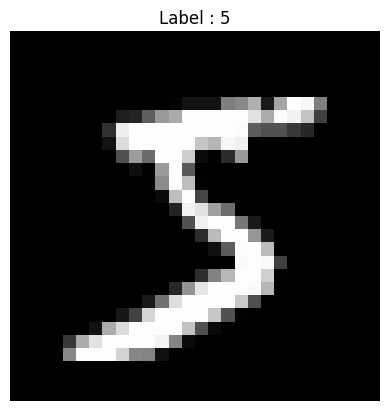

In [ ]:
plt.imshow(digit_image , cmap='gray')
plt.title(f"Label : {digit_label}")
plt.axis('off')
plt.show()

**Reshaping and Scaling Feature Matrices**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

splitting the data into testing and training with train size of 20000

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled , y, train_size = 20000, random_state= 42)

**Train the Baseline Model**

In [ ]:
baseline_model = LinearSVC(dual="auto" , random_state=42)
baseline_model.fit(X_train , y_train)

LinearSVC(random_state=42)

**Evaluation of the Baseline Model**

**Why LinearSVC?**

I selected LinearSVC as my baseline classification model to establish a performance benchmark. This allows for a clean comparison when evaluating more complex models later in the project. By using a linear classifier on flattened pixel vectors, I can effectively assess the improvement gained from non-linear decision boundaries later on.

In [ ]:
y_pred = baseline_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test , y_pred)

In [ ]:
accuracy

0.9026

**What is accuracy value of 0.90 means?**

This is means that the model is 90 percent correct in identifying the target values.

In [ ]:
report = classification_report(y_test , y_pred, output_dict=True)

In [ ]:
df_report = pd.DataFrame(report).transpose()
df_report = df_report.drop('support', axis=1)

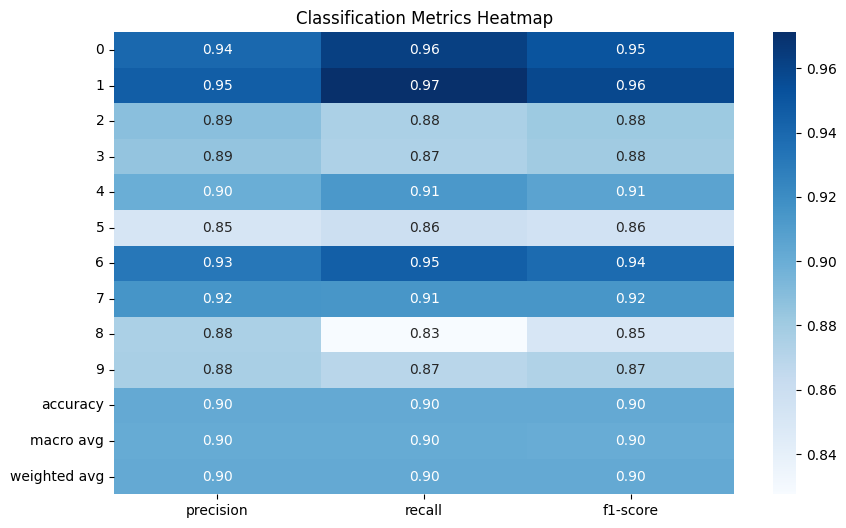

In [ ]:
# plotting as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_report, annot=True, cmap='Blues', fmt=".2f")
plt.title("Classification Metrics Heatmap")
plt.show()

# **Training SVM RBF Kernel Models**

In MNIST tasks, RBF kernels typically outperform linear models because handwritten digits rarely follow strict linear boundaries.

In [ ]:
from sklearn.svm import SVC

In [ ]:
rbf_svm = SVC(kernel='rbf', gamma='scale',random_state=42)

In [ ]:
rbf_svm.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
y_pred_rbf = rbf_svm.predict(X_test)

In [ ]:
classification_report(y_test, y_pred_rbf)

'              precision    recall  f1-score   support\n\n           0       0.98      0.99      0.99      4960\n           1       0.98      0.99      0.98      5593\n           2       0.96      0.97      0.97      4991\n           3       0.97      0.95      0.96      5057\n           4       0.96      0.97      0.97      4825\n           5       0.96      0.96      0.96      4524\n           6       0.98      0.98      0.98      4966\n           7       0.97      0.97      0.97      5247\n           8       0.97      0.95      0.96      4846\n           9       0.96      0.96      0.96      4991\n\n    accuracy                           0.97     50000\n   macro avg       0.97      0.97      0.97     50000\nweighted avg       0.97      0.97      0.97     50000\n'

# **Analyzing Errors with Confusion Matrices**

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred_rbf)

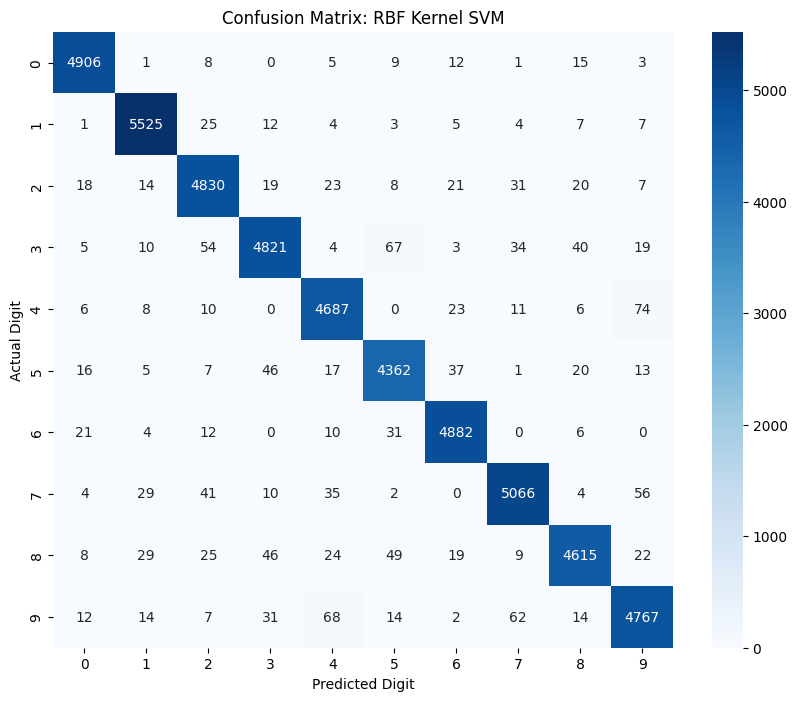

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.ylabel('Actual Digit')
plt.xlabel('Predicted Digit')
plt.title('Confusion Matrix: RBF Kernel SVM')
plt.show()